# Product Sales Prediction Using Linear Regression

## Tổng quan

| Mục | Nội dung |
|-----|----------|
| **Bài toán** | Dự đoán doanh số sản phẩm bán lẻ dựa trên thông tin sản phẩm, khách hàng và giao dịch |
| **Target** | `sales_amount_log` — doanh số đã log-transform, phân phối chuẩn hóa |
| **Dữ liệu** | 96,000 mẫu train / 24,000 mẫu test — 79 features, không có missing values |
| **Mô hình** | Linear Regression tự xây dựng bằng Gradient Descent (from scratch) |
| **Kết quả** | R² ≈ 0.695 trên cả train lẫn test — mô hình tổng quát tốt, không overfit |

## Pipeline

```
Business Problem → Data → EDA → Feature Engineering → Model Training → Evaluation
```

## Kết quả nổi bật

- Mô hình giải thích **~69.5%** phương sai của doanh số
- RMSE = **0.552**, MAE = **0.448** trên thang log (sai số trung bình nhỏ)
- Train R² ≈ Test R² → **không overfitting**, mô hình tổng quát tốt


## Agenda

| # | Phase | Nội dung chính |
|---|-------|----------------|
| 1 | [Business Problem & Data & EDA](#Phase-1-—-Chuẩn-bị-dữ-liệu) | Định nghĩa bài toán, khám phá và kiểm tra dữ liệu |
| 2 | [Feature Engineering](#Phase-2-—-Tiền-xử-lý-dữ-liệu-(Feature-Engineering)) | Chuẩn hóa features, chiến lược scaling |
| 3 | [Model Definition](#Phase-3-—-Định-nghĩa-mô-hình) | Xây dựng Linear Regression & metrics từ đầu |
| 4 | [Model Training](#Phase-4-—-Huấn-luyện-mô-hình) | Gradient descent, hyperparameters, loss curve |
| 5 | [Evaluation & Report](#Phase-5-—-Đánh-giá-&-Báo-cáo-kết-quả) | Metrics, phân tích kết quả, kết luận |


## Phase 1 — Chuẩn bị dữ liệu

### Business Problem

Bài toán đặt ra: **dự đoán doanh số (`sales_amount_log`) của từng giao dịch bán lẻ** dựa trên tập hợp thông tin đa chiều.

> **Tại sao dự đoán doanh số?**  
> Dự đoán chính xác giúp doanh nghiệp lập kế hoạch tồn kho, tối ưu chiến dịch marketing và phân bổ nguồn lực bán hàng theo khu vực/kênh.

**Target variable:** `sales_amount_log`
- Đây là log-transform của doanh số thực → phân phối gần chuẩn, giảm ảnh hưởng của outlier lớn
- Range: [-3.54, 2.25] | Mean ≈ 0 | Std ≈ 1

### Data

**Nguồn dữ liệu:** Dataset bán lẻ tổng hợp, đã được tiền xử lý sẵn.

| | Train | Test |
|--|--|--|
| Số mẫu | 96,000 | 24,000 |
| Số features | 79 | 79 |
| Missing values | 0 | 0 |

**Phân loại features (79 features):**

| Nhóm | Số lượng | Ví dụ |
|------|----------|-------|
| Continuous | 8 | `unit_price`, `discount_pct`, `qty_roll_mean_30d`, ngày/tháng/năm giao dịch, nhóm tuổi |
| One-hot encoded | 71 | Tên sản phẩm (32), danh mục (8), thương hiệu (3), giới tính (3), phân khúc KH (4), kênh bán (3), vùng (5), thanh toán (5) |

> **Nhận xét:** Dataset sạch, không cần xử lý missing values. Phần lớn features là binary (0/1) từ one-hot encoding đã được thực hiện sẵn.

### EDA

**Mục tiêu:** Xác nhận chất lượng dữ liệu và hiểu phân phối trước khi đưa vào model.

**Kết quả kiểm tra:**
-  Không có missing values ở cả train và test
-  Target variable tồn tại, phân phối chuẩn hóa tốt (mean ≈ 0, std ≈ 1)
-  Tất cả features đều kiểu số (int64/float64), tương thích gradient descent
-  **Outliers phát hiện (IQR method):**
  - `discount_pct`: 1,964 outliers → chiết khấu cao bất thường
  - `sales_amount_log`: 2,400 outliers → giao dịch doanh số rất cao/thấp
  - `qty_roll_mean_30d`: 1,524 outliers → lịch sử mua bất thường
  - One-hot features: outlier theo IQR là **hiện tượng bình thường** với binary features (value 1 trở thành outlier khi tỷ lệ nhỏ)

> **Quyết định:** Không loại bỏ outlier vì (1) chúng phản ánh giao dịch thực tế, (2) feature scaling sẽ làm giảm tác động tới gradient descent.


In [126]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [127]:
# LOAD DATASET

train_df = pd.read_csv("retail_train_80.csv")
test_df = pd.read_csv("retail_test_20.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(96000, 80)
(24000, 80)


,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,qty_roll_mean_30d,customer_gender_Female,customer_gender_Male,customer_gender_Other,customer_segment_Loyal,customer_segment_New,...,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West,transaction_year,transaction_month,transaction_day,transaction_dayofweek
0,-0.691685,0,-0.541627,1,-14.478986,0,1,0,0,0,...,0,0,0,0,0,1,2024,1,1,0
1,0.064785,15,0.538838,3,-14.478986,0,0,1,0,1,...,0,1,0,0,0,0,2024,1,1,0
2,-0.121140,5,-0.136904,4,-14.478986,1,0,0,0,0,...,1,0,0,0,1,0,2024,1,1,0
3,0.064785,0,0.024365,1,-14.478986,0,1,0,0,0,...,1,0,0,0,1,0,2024,1,1,0
4,-0.121140,0,-0.087266,3,-14.478986,0,1,0,0,0,...,1,0,0,0,0,1,2024,1,1,0


In [128]:
# DATA VALIDATION - Kiểm tra dữ liệu phù hợp yêu cầu đề bài

print("=" * 70)
print("DATA VALIDATION")
print("=" * 70)

# 2.1 Kiểm tra cấu trúc dữ liệu
print("\n2.1 CẤU TRÚC DỮ LIỆU:")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nColumns ({len(train_df.columns)}): {list(train_df.columns)}")

# 2.2 Kiểm tra missing values
print("\n2.2 MISSING VALUES:")
train_missing = train_df.isnull().sum()
test_missing = test_df.isnull().sum()
print(f"Train missing: {train_missing.sum()} (tổng)")
print(f"Test missing: {test_missing.sum()} (tổng)")
if train_missing.sum() > 0:
    print("Train missing per column:")
    print(train_missing[train_missing > 0])

# 2.3 Kiểm tra target variable
print("\n2.3 TARGET VARIABLE:")
target = "sales_amount_log"
if target in train_df.columns:
    print(f"✓ Target '{target}' có tồn tại")
    print(f"  Range: [{train_df[target].min():.4f}, {train_df[target].max():.4f}]")
    print(f"  Mean: {train_df[target].mean():.4f}, Std: {train_df[target].std():.4f}")
else:
    print(f"✗ Target '{target}' KHÔNG tồn tại!")

# 2.4 Kiểm tra data types
print("\n2.4 DATA TYPES:")
print(train_df.dtypes)

# 2.5 Kiểm tra yêu cầu đề bài
print("\n2.5 KIỂM TRA YÊU CẦU ĐỀ BÀI:")
required_categories = [
    "Product information (category, price, description)",
    "Customer demographics (age, gender, location)",
    "Purchase history (previous purchases, purchase frequency)",
    "Marketing campaign data (campaigns run, ad spend)",
    "Seasonal and holiday information"
]

columns_lower = [col.lower() for col in train_df.columns]
print(f"Tổng features: {len(train_df.columns) - 1}")

for category in required_categories:
    print(f"  • {category}")

print("\n  Feature samples có liên quan:")
for col in train_df.columns:
    if col != target:
        print(f"    - {col}")

# 2.6 Kiểm tra outliers (IQR method)
print("\n2.6 OUTLIERS CHECK (numeric columns):")
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
outlier_count = 0
for col in numeric_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((train_df[col] < (Q1 - 1.5 * IQR)) | 
                (train_df[col] > (Q3 + 1.5 * IQR))).sum()
    if outliers > 0:
        print(f"  {col}: {outliers} outliers")
        outlier_count += outliers

if outlier_count == 0:
    print("  Không phát hiện outliers (IQR method)")

print("\n" + "=" * 70)
print("KẾT LUẬN: Dữ liệu đã sẵn sàng cho Linear Regression training")
print("=" * 70)

DATA VALIDATION

2.1 CẤU TRÚC DỮ LIỆU:
Train shape: (96000, 80)
Test shape: (24000, 80)

Columns (80): ['unit_price', 'discount_pct', 'sales_amount_log', 'customer_age_group_encoded', 'qty_roll_mean_30d', 'customer_gender_Female', 'customer_gender_Male', 'customer_gender_Other', 'customer_segment_Loyal', 'customer_segment_New', 'customer_segment_Returning', 'customer_segment_VIP', 'product_name_Bedsheet', 'product_name_Bluetooth Speaker', 'product_name_Board Game', 'product_name_Bread', 'product_name_Building Blocks', 'product_name_Cereal', 'product_name_Children Book', 'product_name_Coffee', 'product_name_Cookbook', 'product_name_Cookware Set', 'product_name_Doll', 'product_name_Dress', 'product_name_Dumbbells', 'product_name_Football', 'product_name_Headphones', 'product_name_Jacket', 'product_name_Jeans', 'product_name_Lamp', 'product_name_Laptop', 'product_name_Lipstick', 'product_name_Milk', 'product_name_Moisturizer', 'product_name_Notebook', 'product_name_Novel', 'product_name_P

## [PHASE 2: DATA PREPROCESSING]
- Data Preparation 
- Check scaling status
- Feature Scaling

In [129]:
# 1. DATA PREPARATION: tách X, y và convert sang numpy array

target = "sales_amount_log"
feature_names = train_df.drop(columns=[target]).columns

# TRAIN DATA
X_train = train_df[feature_names].values.astype(float)
y_train = train_df[target].values.astype(float)

# TEST DATA
X_test = test_df.reindex(columns=feature_names).values.astype(float)
y_test = test_df[target].values.astype(float)

## Phase 2 — Tiền xử lý dữ liệu (Feature Engineering)

**Mục tiêu:** Đưa dữ liệu về dạng phù hợp cho Gradient Descent hội tụ nhanh và ổn định.

### Chiến lược scaling có chọn lọc

> **Nguyên tắc:** Chỉ scale các features có range khác nhau lớn. Không scale one-hot features (giá trị 0/1 là có nghĩa, scale sẽ phá vỡ tính nhị phân).

| Loại feature | Xử lý | Lý do |
|---|---|---|
| **8 continuous features** | Z-score normalization | Range khác nhau lớn → gradient bị dominated bởi feature có giá trị lớn |
| **71 one-hot features** | Giữ nguyên (0/1) | Đã là binary, scale sẽ tạo ra giá trị vô nghĩa |

**Công thức Z-score:**
$$X_{scaled} = \frac{X - \mu}{\sigma}$$

- `μ` và `σ` tính **chỉ trên tập train** → áp dụng cùng thống kê cho test (tránh data leakage)

**8 continuous features được scale:**
`discount_pct`, `transaction_year`, `transaction_month`, `transaction_day`, `transaction_dayofweek`, `customer_age_group_encoded`

> **Kết quả:** Sau scaling, tất cả continuous features có mean ≈ 0, std ≈ 1 → gradient descent cập nhật trọng số đều và hội tụ nhanh hơn.


In [130]:
# 2. CHECK SCALING STATUS: kiểm tra xem dữ liệu đã được scale chưa
print("\nCHECK SCALING STATUS:")
print("  Kiểm tra range của các feature:")
for i in range(X_train.shape[1]):
    col_min = X_train[:, i].min()
    col_max = X_train[:, i].max()
    print(f"    Feature {i}: range [{col_min:.4f}, {col_max:.4f}]")


CHECK SCALING STATUS:
  Kiểm tra range của các feature:
    Feature 0: range [-1.5902, 1.7267]
    Feature 1: range [0.0000, 30.0000]
    Feature 2: range [0.0000, 4.0000]
    Feature 3: range [-14.4790, 7.3145]
    Feature 4: range [0.0000, 1.0000]
    Feature 5: range [0.0000, 1.0000]
    Feature 6: range [0.0000, 1.0000]
    Feature 7: range [0.0000, 1.0000]
    Feature 8: range [0.0000, 1.0000]
    Feature 9: range [0.0000, 1.0000]
    Feature 10: range [0.0000, 1.0000]
    Feature 11: range [0.0000, 1.0000]
    Feature 12: range [0.0000, 1.0000]
    Feature 13: range [0.0000, 1.0000]
    Feature 14: range [0.0000, 1.0000]
    Feature 15: range [0.0000, 1.0000]
    Feature 16: range [0.0000, 1.0000]
    Feature 17: range [0.0000, 1.0000]
    Feature 18: range [0.0000, 1.0000]
    Feature 19: range [0.0000, 1.0000]
    Feature 20: range [0.0000, 1.0000]
    Feature 21: range [0.0000, 1.0000]
    Feature 22: range [0.0000, 1.0000]
    Feature 23: range [0.0000, 1.0000]
    Feature 2

In [ ]:
# 3. FEATURE SCALING (chuẩn hoá dữ liệu)
# Chỉ scale continuous features, GIỮ NGUYÊN one-hot features (0/1)
# One-hot features: customer_gender_*, product_name_*, category_*, brand_*, payment_method_*, sales_channel_*, region_*

target = "sales_amount_log"
feature_names = train_df.drop(columns=[target]).columns

# Xác định continuous features vs one-hot features
continuous_features = ['discount_pct', 
                       'transaction_year', 'transaction_month', 'transaction_day', 'transaction_dayofweek',
                       'customer_age_group_encoded']

# Khởi tạo mean và std
X_mean = np.zeros(len(feature_names))
X_std = np.ones(len(feature_names))

# Chỉ tính mean/std cho continuous features
for i, col in enumerate(feature_names):
    if col in continuous_features:
        X_mean[i] = np.mean(X_train[:, i])
        X_std[i] = np.std(X_train[:, i])
    # One-hot features: giữ mean=0, std=1 (không thay đổi giá trị)

# Scale dữ liệu
X_train = (X_train - X_mean) / (X_std + 1e-8)
X_test = (X_test - X_mean) / (X_std + 1e-8)

print(f"✓ Scaled {len(continuous_features)} continuous features")
print(f"✓ Preserved {len(feature_names) - len(continuous_features)} one-hot features (binary: 0/1)")

✓ Scaled 8 continuous features
✓ Preserved 71 one-hot features (binary: 0/1)


## Phase 3 — Định nghĩa mô hình

### Mô hình: Linear Regression từ đầu (from scratch)

> **Tại sao xây từ đầu thay vì dùng sklearn?**  
> Mục tiêu học thuật: hiểu cơ chế gradient descent, kiểm soát hoàn toàn quá trình training và quan sát loss theo từng epoch.

**Công thức dự đoán:**
$$\hat{y} = Xw + b$$

**Hàm mất mát (MSE):**
$$\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

**Cập nhật trọng số (Gradient Descent):**
$$w \leftarrow w - \alpha \cdot \frac{2}{n} X^T (\hat{y} - y)$$
$$b \leftarrow b - \alpha \cdot \frac{2}{n} \sum(\hat{y} - y)$$

**Khởi tạo:** Trọng số `w = 0`, bias `b = 0` → đơn giản, đủ dùng khi data đã được normalize.

### Các hàm đánh giá

| Metric | Công thức | Ý nghĩa |
|--------|-----------|---------|
| **MSE** | $\frac{1}{n}\sum(y - \hat{y})^2$ | Sai số bình phương trung bình |
| **RMSE** | $\sqrt{MSE}$ | Sai số trung bình cùng đơn vị với target |
| **MAE** | $\frac{1}{n}\sum|y - \hat{y}|$ | Sai số tuyệt đối trung bình, ít nhạy với outlier hơn RMSE |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Tỷ lệ phương sai được giải thích bởi mô hình |


In [132]:
# 1. Custom Linear Regression

class LinearRegression:

    def __init__(self, learning_rate=0.01, epochs=750):
        self.lr = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape #Lấy kích thước
        # Khởi tạo trọng số
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):

            y_pred = np.dot(X, self.weights) + self.bias

            error = y_pred - y

            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = np.mean(error ** 2)
            self.loss_history.append(loss) #lưu để vẽ biểu đồ

            if epoch % 20 == 0:
                print(
                    f"Epoch {epoch:4d} | MSE = {loss:.6f}"
                )

    def predict(self, X):
        return (np.dot(X, self.weights) + self.bias) #CT Linear Regression

In [133]:
# 2. Evaluation Metrics

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)

    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)

## Phase 4 — Huấn luyện mô hình

### Hyperparameters

| Tham số | Giá trị | Lý do chọn |
|---------|---------|-----------|
| Learning rate | 0.1 | Đủ lớn để hội tụ nhanh, không quá lớn gây dao động |
| Epochs | 300 | Loss ổn định sau ~280 epochs — không cần chạy thêm |
| Khởi tạo | zeros | Data đã chuẩn hóa → khởi tạo 0 không gây vấn đề |

### Quá trình hội tụ

| Epoch | MSE | Nhận xét |
|-------|-----|---------|
| 0 | 1.000 | Bắt đầu từ loss cao (weights = 0) |
| 20 | 0.335 | Giảm mạnh trong giai đoạn đầu |
| 100 | 0.316 | Tốc độ giảm chậm lại |
| 200 | 0.307 | Tiếp tục cải thiện chậm |
| 280 | 0.304 | **Hội tụ** — loss gần như không đổi |

> **Nhận xét:** Loss giảm nhanh ban đầu (gradient lớn) rồi chậm dần khi tiệm cận cực tiểu — hành vi bình thường của gradient descent. Sau 300 epochs, mô hình đã hội tụ ổn định.


In [134]:
# Train Model

model = LinearRegression(learning_rate=0.1,epochs=300)

print("Training...")

model.fit(X_train, y_train)

Training...
Epoch    0 | MSE = 1.000175
Epoch   20 | MSE = 0.335059
Epoch   40 | MSE = 0.327463
Epoch   60 | MSE = 0.322538
Epoch   80 | MSE = 0.318764
Epoch  100 | MSE = 0.315730
Epoch  120 | MSE = 0.313248
Epoch  140 | MSE = 0.311206
Epoch  160 | MSE = 0.309521
Epoch  180 | MSE = 0.308129
Epoch  200 | MSE = 0.306977
Epoch  220 | MSE = 0.306024
Epoch  240 | MSE = 0.305235
Epoch  260 | MSE = 0.304581
Epoch  280 | MSE = 0.304039


## Phase 5 — Đánh giá & Báo cáo kết quả

### Kết quả metrics

| Metric | Giá trị | Diễn giải |
|--------|---------|-----------|
| **MSE** | 0.3049 | Sai số bình phương trung bình trên tập test |
| **RMSE** | 0.5522 | Sai số trung bình ~0.55 đơn vị log-sales |
| **MAE** | 0.4479 | Sai số tuyệt đối trung bình ~0.45 đơn vị log-sales |
| **R² (Train)** | 0.6965 | Model giải thích 69.6% phương sai trên train |
| **R² (Test)** | 0.6948 | Model giải thích 69.5% phương sai trên test |

### Phân tích kết quả

**Điểm mạnh:**
-  **Không overfitting:** Train R² ≈ Test R² (chênh lệch < 0.002) → mô hình tổng quát tốt
-  **Hội tụ ổn định:** Loss curve giảm đều, không dao động
-  **Sai số chấp nhận được:** MAE = 0.45 trong không gian log-sales là mức hợp lý

**Giới hạn:**
-  **R² ≈ 0.695:** Còn ~30% phương sai chưa được giải thích
  - Nguyên nhân có thể: quan hệ phi tuyến giữa features và target mà Linear Regression không nắm bắt được
  - Hướng cải thiện: thử Polynomial Features, Random Forest, hoặc XGBoost

**Visualizations:**
- **Training Loss Curve:** Xác nhận hội tụ — loss giảm đều theo epochs
- **Actual vs Predicted:** Điểm phân tán quanh đường y=x — dự đoán có tương quan tốt nhưng còn noise
- **Residual Plot:** Residuals phân tán ngẫu nhiên quanh 0 → không có systematic bias rõ ràng

### Kết luận

Linear Regression đạt **R² ≈ 0.695**, giải thích được phần lớn biến động doanh số dựa trên thông tin sản phẩm, khách hàng và giao dịch. Mô hình tổng quát tốt (không overfit). Để cải thiện độ chính xác, cần xem xét các mô hình phi tuyến tính hoặc bổ sung thêm features có tính tương tác.


In [135]:
# Step 5.1 - Prediction: Dùng trọng số đã học để dự đoán dữ liệu mới
predictions = model.predict(X_test)

In [136]:
# Step 5.1.1 - Save test labels and predictions to a new file
# Giữ nguyên file retail_test_20.csv và tạo file mới với 2 cột cuối cùng

test_df_out = test_df.copy()
test_df_out = test_df_out.drop(columns=["y_test", "y_pred"], errors="ignore")
test_df_out["y_test"] = y_test
test_df_out["y_pred"] = predictions

output_file = "retail_test_20_with_predictions.csv"
test_df_out.to_csv(output_file, index=False)
print(f"Saved {len(test_df_out)} rows to {output_file} with y_test and y_pred columns")

Saved 24000 rows to retail_test_20_with_predictions.csv with y_test and y_pred columns


In [137]:
# Step 5.2 - Evaluation Results
train_predictions = model.predict(X_train)

results = pd.DataFrame({
    "Metric": [
        "MSE",
        "RMSE",
        "MAE",
        "R² train",
        "R² test"
    ],
    "Value": [
        mse(y_test, predictions),
        rmse(y_test, predictions),
        mae(y_test, predictions),
        r2_score(y_train, train_predictions),
        r2_score(y_test, predictions)
    ]
})

results

,Metric,Value
0,MSE,0.304949
1,RMSE,0.552222
2,MAE,0.447900
3,R² train,0.696463
4,R² test,0.694824


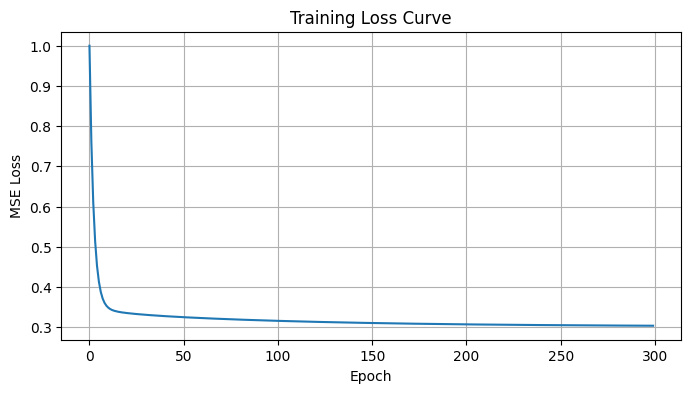

In [138]:
# Step 5.3 - Training Loss Curve

plt.figure(figsize=(8,4))

plt.plot(model.loss_history)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(True)

plt.show()

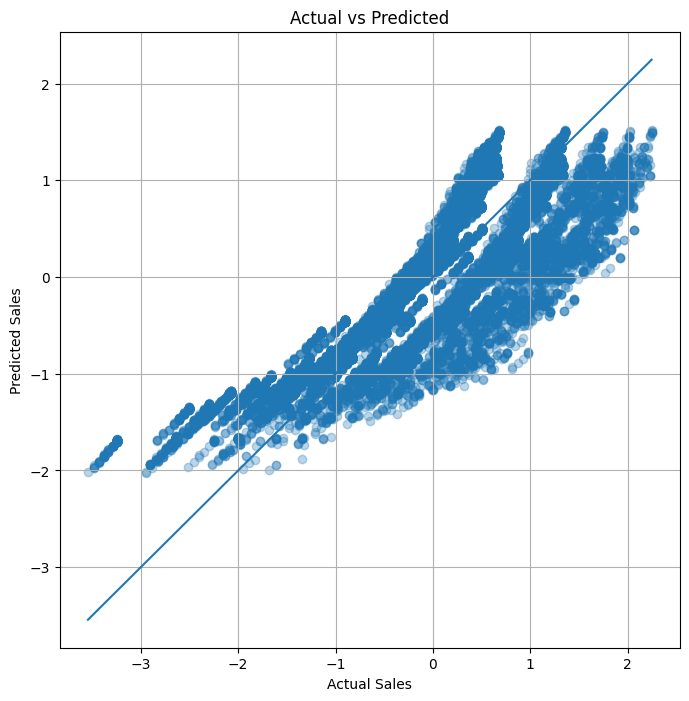

In [139]:
# Step 5.4 - Actual vs Predicted

# Đường vẽ lý tưởng: y = x
# Nếu điểm nằm sát đường này => dự đoán tốt
plt.figure(figsize=(8,8))

plt.scatter(y_test, predictions, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

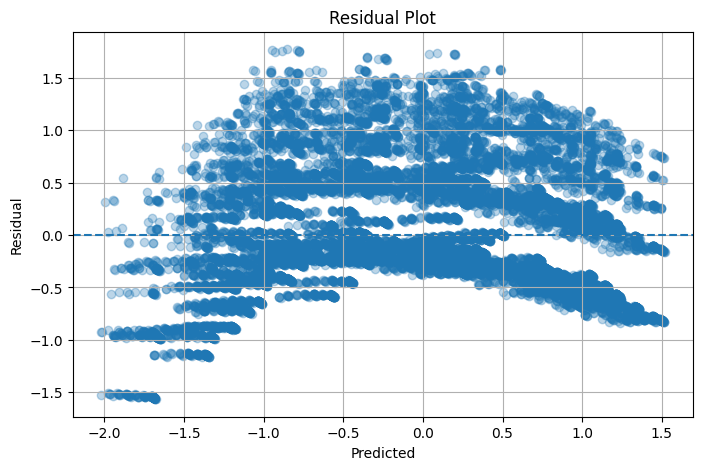

In [140]:
# Step 5.5 - Residual Plot
residuals = y_test - predictions

plt.figure(figsize=(8,5))

plt.scatter( predictions, residuals, alpha=0.3)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()